<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Convergence comparison between batch norm and layer norm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [6]:
torch.manual_seed(42)

X=torch.randn(500,100)
y=torch.randn(500,1)


def create_model(norm_type='batch'):
  layers=[]
  in_dim=100
  for _ in range(5):
    layers.append(nn.Linear(in_dim,100))
    if norm_type=='batch':
      layers.append(nn.BatchNorm1d(100))
    else:
      layers.append(nn.LayerNorm(100))
    layers.append(nn.ReLU())
  layers.append(nn.Linear(100,1))
  return nn.Sequential(*layers)


def train(model,batch_size=8):
  optimizer=optim.Adam(model.parameters(),lr=0.001)
  criterion=nn.MSELoss()
  losses=[]

  for epoch in range(100):
    permutation=torch.randperm(X.size(0))
    epoch_loss=0
    for i in range(0,X.size(0),batch_size):
      indices=permutation[i:i+batch_size]

      batch_x,batch_y=X[indices],y[indices]
      loss=criterion(model(batch_x),batch_y)
      loss.backward()
      optimizer.step()
      epoch_loss+=loss.item()
    losses.append(epoch_loss/(X.size(0)/batch_size))
  return losses

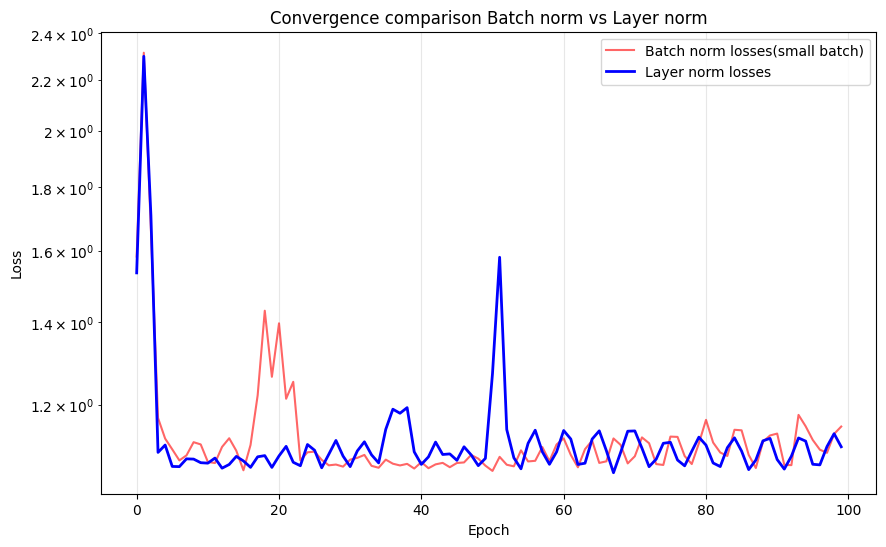

In [7]:
model_bn=create_model('batch')
model_ln=create_model('layer')

losses_bn=train(model_bn,batch_size=4)
losses_ln=train(model_ln,batch_size=4)

plt.figure(figsize=(10,6))
plt.plot(losses_bn,label="Batch norm losses(small batch)",color='red',alpha=0.6)
plt.plot(losses_ln,label="Layer norm losses",color='blue',linewidth=2)
plt.yscale('log')
plt.title("Convergence comparison Batch norm vs Layer norm")
plt.xlabel("Epoch")
plt.ylabel('Loss')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()